In [1]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
print('✓ Malgun Gothic 폰트 설정 완료')
print('font.family ->', matplotlib.rcParams['font.family'])

✓ Malgun Gothic 폰트 설정 완료
font.family -> ['Malgun Gothic']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 펭귄 데이터 로드 (Seaborn에서 제공하는 내장 데이터)
print('펭귄 데이터 로드 중...')
df = sns.load_dataset('penguins')
print(f'✓ 로드 완료: shape {df.shape}')
print('\n데이터 정보:')
print(df.info())

펭귄 데이터 로드 중...
✓ 로드 완료: shape (344, 7)

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


In [3]:
print('\n=== 데이터 상위 5행 ===')
print(df.head())
print('\n=== 결측치 요약 ===')
print(df.isnull().sum())
print('\n=== 기본 통계 ===')
print(df.describe())


=== 데이터 상위 5행 ===
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

=== 결측치 요약 ===
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

=== 기본 통계 ===
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170

In [4]:
# 종별(species) 펭귄 개수
print('종별 펭귄 개수:')
print(df['species'].value_counts())
print('\n섬별(island) 펭귄 개수:')
print(df['island'].value_counts())

종별 펭귄 개수:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

섬별(island) 펭귄 개수:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


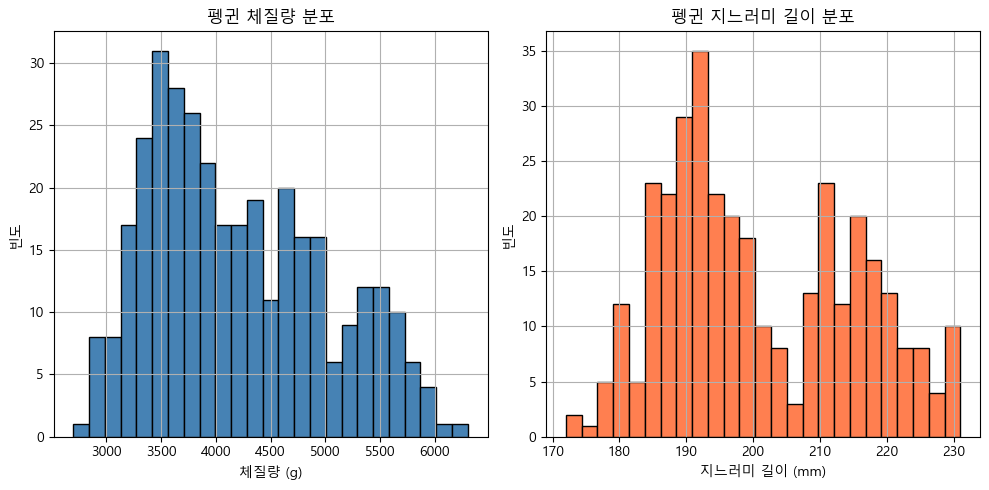

✓ plot_1_histogram.png 저장됨


In [5]:
# 히스토그램: 체질량
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['body_mass_g'].dropna().hist(bins=25, color='steelblue', edgecolor='black')
plt.xlabel('체질량 (g)')
plt.ylabel('빈도')
plt.title('펭귄 체질량 분포')

# 히스토그램: 지느러미 길이
plt.subplot(1, 2, 2)
df['flipper_length_mm'].dropna().hist(bins=25, color='coral', edgecolor='black')
plt.xlabel('지느러미 길이 (mm)')
plt.ylabel('빈도')
plt.title('펭귄 지느러미 길이 분포')

plt.tight_layout()
plt.savefig('plot_1_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ plot_1_histogram.png 저장됨')

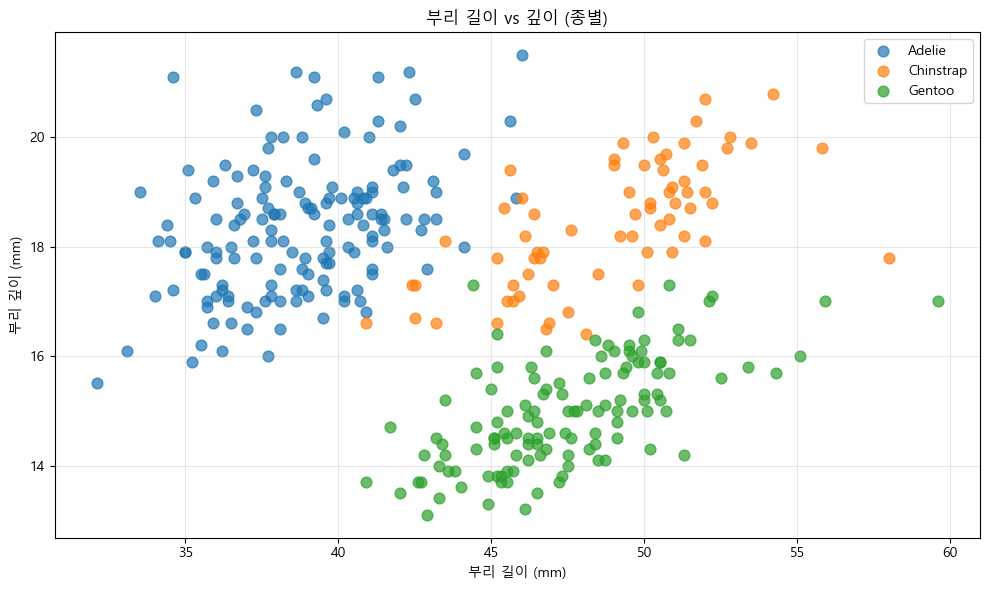

✓ plot_2_scatter.png 저장됨


In [6]:
# 산점도: 부리 길이 vs 부리 깊이 (종별 색상)
plt.figure(figsize=(10, 6))
species_colors = {'Adelie': 'C0', 'Chinstrap': 'C1', 'Gentoo': 'C2'}
for species in df['species'].unique():
    mask = df['species'] == species
    plt.scatter(df[mask]['bill_length_mm'], df[mask]['bill_depth_mm'], 
                label=species, alpha=0.7, s=60, color=species_colors.get(species))
plt.xlabel('부리 길이 (mm)')
plt.ylabel('부리 깊이 (mm)')
plt.title('부리 길이 vs 깊이 (종별)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_2_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ plot_2_scatter.png 저장됨')

C:\Users\ejgo6\AppData\Local\Temp\ipykernel_17256\2767939909.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(flipper_by_species, labels=species_list)
C:\Users\ejgo6\AppData\Local\Temp\ipykernel_17256\2767939909.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(mass_by_sex, labels=sex_list)


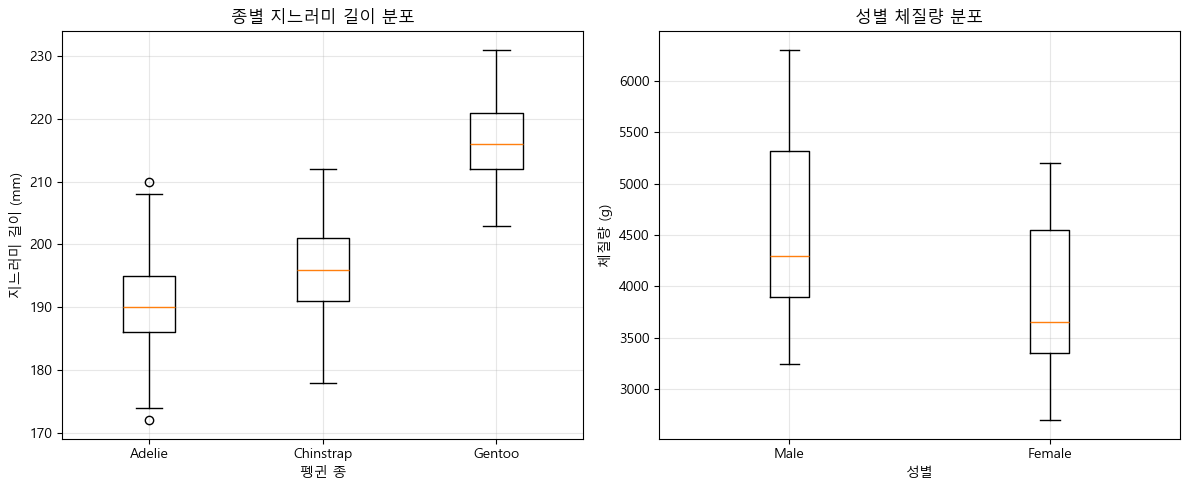

✓ plot_3_boxplot.png 저장됨


In [7]:
# 박스플롯: 지느러미 길이 by 종
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 종별 지느러미 길이 박스플롯
species_list = df['species'].dropna().unique()
flipper_by_species = [df[df['species'] == sp]['flipper_length_mm'].dropna() for sp in species_list]
axes[0].boxplot(flipper_by_species, labels=species_list)
axes[0].set_xlabel('펭귄 종')
axes[0].set_ylabel('지느러미 길이 (mm)')
axes[0].set_title('종별 지느러미 길이 분포')
axes[0].grid(True, alpha=0.3)

# 성별 체질량 박스플롯
sex_list = df['sex'].dropna().unique()
mass_by_sex = [df[df['sex'] == s]['body_mass_g'].dropna() for s in sex_list]
axes[1].boxplot(mass_by_sex, labels=sex_list)
axes[1].set_xlabel('성별')
axes[1].set_ylabel('체질량 (g)')
axes[1].set_title('성별 체질량 분포')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_3_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ plot_3_boxplot.png 저장됨')

In [8]:
# 상관계수 분석
print('\n=== 수치형 변수 간 상관계수 ===')
print(df.corr(numeric_only=True).round(3))


=== 수치형 변수 간 상관계수 ===
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.235              0.656   
bill_depth_mm              -0.235          1.000             -0.584   
flipper_length_mm           0.656         -0.584              1.000   
body_mass_g                 0.595         -0.472              0.871   

                   body_mass_g  
bill_length_mm           0.595  
bill_depth_mm           -0.472  
flipper_length_mm        0.871  
body_mass_g              1.000  


In [9]:
# 요약
print('\n' + '='*50)
print('펭귄 데이터 EDA 완료')
print('='*50)
print(f'- 총 {len(df)}개의 펭귄 레코드')
print(f'- {df["species"].nunique()}개의 종: {list(df["species"].unique())}')
print(f'- {df["island"].nunique()}개의 섬: {list(df["island"].unique())}')
print(f'- 결측치: {df.isnull().sum().sum()}개')
print('\n생성된 플롯:')
print('- plot_1_histogram.png: 체질량 및 지느러미 길이 분포')
print('- plot_2_scatter.png: 부리 길이 vs 깊이 (종별 색상)')
print('- plot_3_boxplot.png: 종별/성별 박스플롯')


펭귄 데이터 EDA 완료
- 총 344개의 펭귄 레코드
- 3개의 종: ['Adelie', 'Chinstrap', 'Gentoo']
- 3개의 섬: ['Torgersen', 'Biscoe', 'Dream']
- 결측치: 19개

생성된 플롯:
- plot_1_histogram.png: 체질량 및 지느러미 길이 분포
- plot_2_scatter.png: 부리 길이 vs 깊이 (종별 색상)
- plot_3_boxplot.png: 종별/성별 박스플롯
